In [ ]:
# Adaptado de: Meduri Venkata Shivaditya
!pip install bayes_logistic
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
import bayes_logistic #
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


Creamos el conjunto de datos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import datasets
from sklearn.decomposition import PCA

iris = datasets.load_iris()

XXX = iris["data"][0:150, :]  # petal width
y = (iris["target"] == 1).astype(int)  # 1 if Iris-Virginica, else 0

# Obtener 2 componentes principales para graficar en 2D
pca = PCA(n_components=2)
XX = pca.fit_transform(XXX)

# Calcular la media de cada columna
mean = np.mean(XX, axis=0)

# Calcular la desviación estándar de cada columna
std = np.std(XX, axis=0)

# Normalizar los datos con media 0
X = (XX - mean) / std

X_1 = X[0:30] # Setosas
X_2 = X[50:80] # Versicolor
mu1= np.mean(X_1)
mu2= np.mean(X_2)

class1_std =  np.std(X_1)
class2_std =  np.std(X_2)

print(class2_std)
N = 30
D = 2
"""
np.random.seed(135)
#Creating data
N = 30
D = 2
#mu1 = np.hstack((np.ones((N,1)), 5 * np.ones((N, 1))))
#mu2 = np.hstack((-5 * np.ones((N,1)), np.ones((N, 1))))
class1_std = 1
class2_std = 1.1
X_1 = np.add(class1_std*np.random.randn(N,2), mu1)
X_2 = np.add(2*class2_std*np.random.randn(N,2), mu2)
"""
X = np.vstack((X_1,X_2)) # Features
t = np.vstack((np.zeros((N,1)),np.ones((N,1)))) # Labels
#print(XX)
#print(t)
print(np.shape(X), np.shape(t))

0.7597733376193989
(60, 2) (60, 1)


Visualizamos los datos

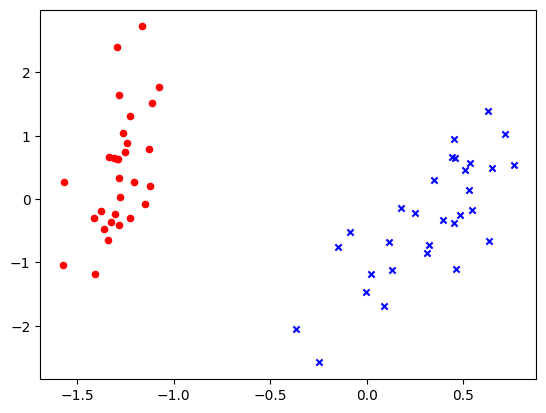

In [ ]:
#Plotting data
x_1, y_1 = X[np.where(t==0)[0]].T
x_2, y_2 = X[np.where(t==1)[0]].T
plt.figure(0)
plt.scatter(x_1,y_1,c = 'red', s=20, marker = 'o')
plt.scatter(x_2,y_2,c = 'blue', s = 20, marker = 'x')

Gráficamos distintos limites de decisión

(100, 100) (100, 100)


Text(0.5, 1.0, 'data')

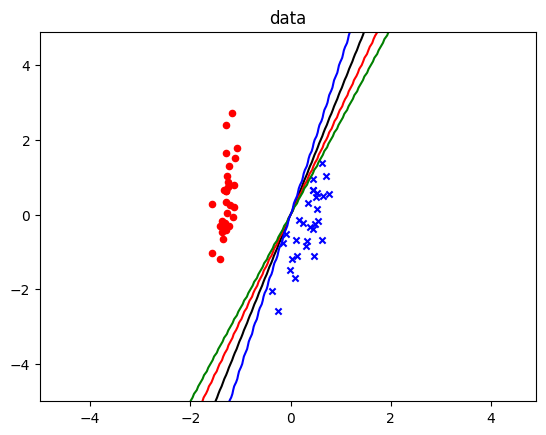

In [ ]:
#Plotting data
x_1, y_1 = X[np.where(t==0)[0]].T
x_2, y_2 = X[np.where(t==1)[0]].T
plt.figure(0)
plt.scatter(x_1,y_1,c = 'red', s=20, marker = 'o')
plt.scatter(x_2,y_2,c = 'blue', s = 20, marker = 'x')

#Plotting Predictions
Range = 5
step = 0.1 #0.9
xx, yy = np.meshgrid(np.arange(-Range,Range,step),np.arange(-Range,Range,step))
print(np.shape(xx), np.shape(yy))
[n,n] = xx.shape
W = np.hstack((xx.reshape((n*n, 1)),yy.reshape((n*n, 1))))
Xgrid = W
ws = np.array([[20, -6], [34, -12], [35, -14], [37, -9]]) # Limites de decisión %3 interception 4,2 pendiente
col = ['black', 'red', 'green', 'blue']
for ii in range(ws.shape[0]):
    w = ws[ii][:]
    logits = np.dot(Xgrid,w)
    pred = 1.0/(1+np.exp(-logits)) # sigmoid
    plt.contour(xx, yy, pred.reshape((n, n)), 1, colors=col[ii])
plt.title("data")

Gráficamos la prior

[[1075.    0.]
 [   0. 1075.]]


Text(0.5, 1.0, 'Log-Prior')

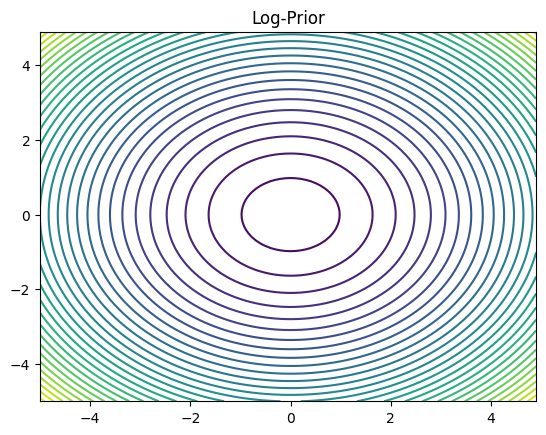

In [ ]:
#Plot prior, likelihood, posterior
alpha = 1075
Xt = np.transpose(X)
f=np.dot(W,Xt)
print(np.identity(D)*alpha)
log_prior = np.log(multivariate_normal.pdf(W, cov=(np.identity(D))*alpha))

log_like = np.dot(np.dot(W, Xt), t) - np.sum(np.log(1+np.exp(f)), 1).reshape((n*n,1))
log_joint = log_like.reshape((n*n,1)) + log_prior.reshape((n*n,1))

#Plotting log-prior
plt.figure(1)
plt.contour(xx, yy, -1*log_prior.reshape((n,n)), 30)
plt.title("Log-Prior")

Gráficamos el likelihood

-0.34693877551020896


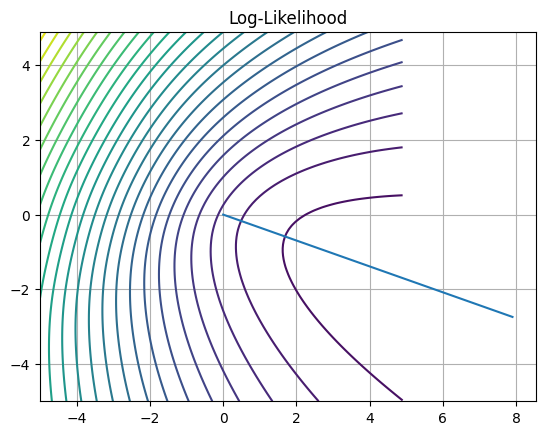

In [ ]:
plt.figure(1)
plt.contour(xx, yy, -1*log_like.reshape((n,n)), 30)
plt.title("Log-Likelihood")

#Plotting points corresponding to chosen lines
for ii in range(0, ws.shape[0]):
    w = np.transpose(ws[ii, :])
    plt.annotate(str(ii+1), xy=(w[0], w[1]), color=col[ii])

j=np.argmax(log_like)
wmle = W[j, :]
slope = wmle[1] / wmle[0]
#plt.axline([wmle[0], wmle[1]], slope=slope)
print(slope)
plt.plot([0, 7.9], [0, 7.9*slope])
plt.grid()

Gráficamos la posterior sin normalizar

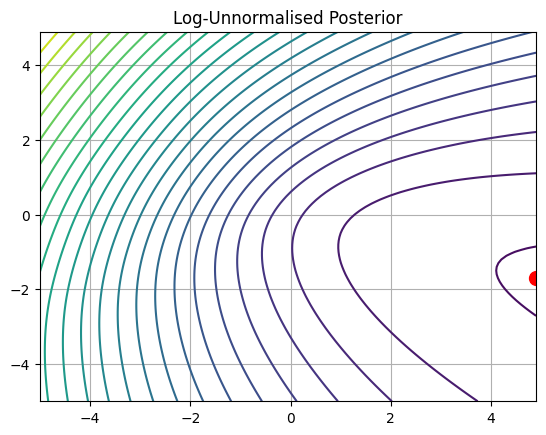

In [ ]:
#Plotting the log posterior(Unnormalised
plt.figure(2)
plt.contour(xx,yy,-1*log_joint.reshape((n,n)), 30)
plt.title("Log-Unnormalised Posterior")
j2=np.argmax(log_joint)
wb = W[j2][:]
plt.scatter(wb[0], wb[1], c='red' , s = 100)
plt.grid()

Entrenamos el modelo de regresión logística bayesiana

In [ ]:
#https://bayes-logistic.readthedocs.io/en/latest/usage.html
#Visit the website above to access the source code of bayes_logistic library
#parameter info : bayes_logistic.fit_bayes_logistic(y, X, wprior, H, weights=None, solver='Newton-CG', bounds=None, maxiter=100)
wfit, hfit = bayes_logistic.fit_bayes_logistic(t.reshape((N*D)), X, np.zeros(D), ((np.identity(D))*1/alpha), weights=None, solver='Newton-CG', bounds=None, maxiter=100)
co = np.linalg.inv(hfit)
#wfit represents the posterior parameters (MAP estimate)
#hfit represents the posterior Hessian  (Hessian of negative log posterior evaluated at MAP parameters)

Gráficamos la posterior normalizada

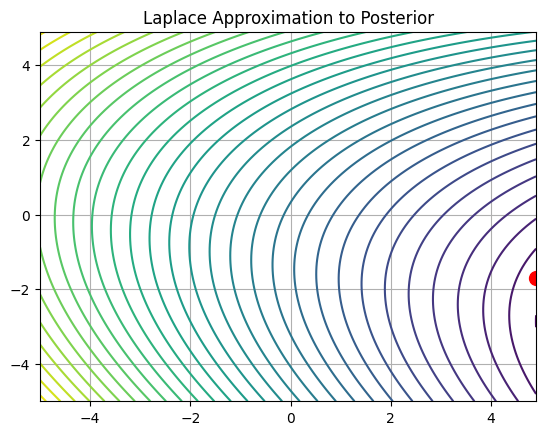

In [ ]:
log_laplace_posterior = np.log(multivariate_normal.pdf(W, mean = wfit, cov=co))
plt.contour(xx, yy, -1*log_laplace_posterior.reshape((n,n)), 30)
plt.scatter(wb[0], wb[1], c='red' , s = 100)
plt.title("Laplace Approximation to Posterior")
plt.grid()

Graficamos la distribución predictiva

Text(0.5, 1.0, 'p(y=1|x, wMAP)')

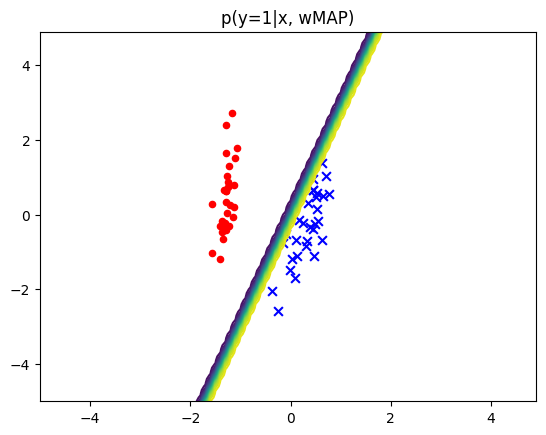

In [ ]:
#Plotting the predictive distribution for logistic regression
plt.figure(5)
logits=np.dot(Xgrid,wfit) #  y=w1x+w2
pred = 1.0/(1+np.exp(-logits))
plt.contour(xx, yy, pred.reshape((n,n)), 30)
x_1, y_1 = X[np.where(t == 0)[0]].T
x_2, y_2 = X[np.where(t == 1)[0]].T
plt.scatter(x_1, y_1, c='red', s=20, marker='o')
plt.scatter(x_2, y_2, c = 'blue', s=40, marker = 'x')
plt.title("p(y=1|x, wMAP)")

Limite de decisión para diversos pesos muestreados

Text(0.5, 1.0, 'Decision boundary for sampled w')

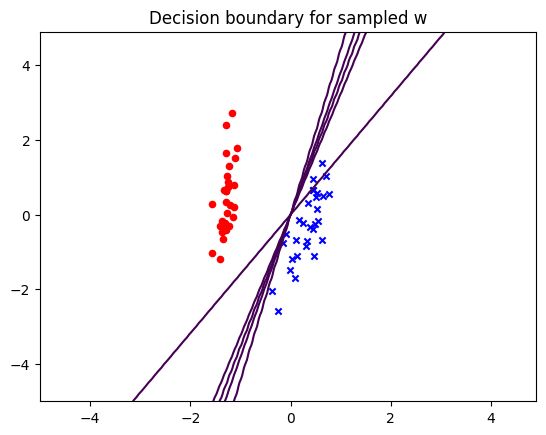

In [ ]:
#Decision boundary for sampled w
plt.figure(6)
plt.scatter(x_1, y_1, c='red', s=20, marker='o')
plt.scatter(x_2, y_2, c='blue', s=20, marker='x')

s = 5
for i in range(s):
    wsamp = np.random.multivariate_normal(mean = wfit, cov=co)
    pred = 1.0/(1+np.exp(np.dot(-Xgrid,wsamp)))
    plt.contour(xx, yy, pred.reshape((n,n)), np.array([0.5]))
plt.title("Decision boundary for sampled w")

MC approximation

Text(0.5, 1.0, 'MC approx of p(y=1|x)')

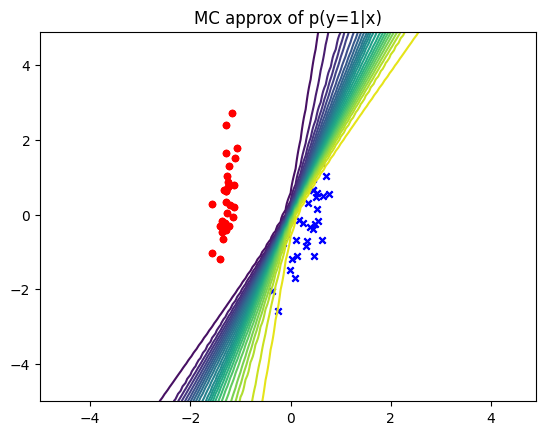

In [ ]:
#MC
plt.figure(7)
plt.scatter(x_1, y_1, c='red', s=20, marker='o')
plt.scatter(x_2, y_2, c='blue', s=20, marker='x')

predm = np.zeros((n*n,1))
s = 50
for i in range(s):
    wsamp = np.random.multivariate_normal(mean = wfit, cov=co)
    pred = 1.0/(1+np.exp(np.dot(-Xgrid,wsamp)))
    predm = np.add(predm, pred.reshape((n*n, 1)))

predm = predm/s
plt.contour(xx, yy, predm.reshape((n,n)), 30)
plt.scatter(x_1, y_1, c='red', s=20, marker='o')
plt.scatter(x_2, y_2, c='blue', s=20, marker='x')
plt.title("MC approx of p(y=1|x)")

In [ ]:
predm = np.zeros((n*n,1))
s = 100
pred_list = []
for i in range(s):
    wsamp = np.random.multivariate_normal(mean = wfit, cov=co)
    pred = 1.0/(1+np.exp(np.dot(-Xgrid,wsamp)))
    pred_list.append(pred)
    predm = np.add(predm, pred.reshape((n*n, 1)))

v = np.var(pred_list, axis=0)
pred_f = np.mean(pred_list, axis=0)
print(Xgrid[150], v[150], pred_f[150])
predm = predm/s

print(np.shape(Xgrid))
x_new = np.array([[2,5]])
print(np.shape(x_new))
for i in range(s):
    wsamp = np.random.multivariate_normal(mean = wfit, cov=co)
    pred = 1.0/(1+np.exp(np.dot(-x_new,wsamp)))
    pred_list.append(pred)


print(x_new[0], v[0], pred_f[0])


[-1.77635684e-14 -4.90000000e+00] 1.2555206443145902e-13 0.9999999453891135
(10000, 2)
(1, 2)
[2 5] 0.009455012684302336 0.00979832980885031


Probit approximation

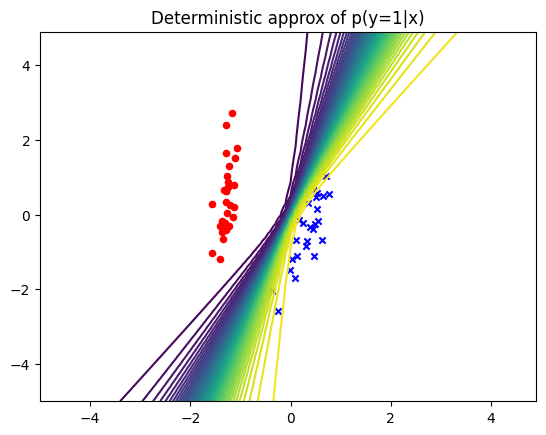

In [ ]:
#Numerical
plt.figure(8)
plt.scatter(x_1, y_1, c='red', s=20, marker='o')
plt.scatter(x_2, y_2, c='blue', s=20, marker='x')

m = np.dot(Xgrid, wfit)
cov = np.linalg.inv(hfit)
v = np.sum(Xgrid * np.dot(cov, Xgrid.T).T, axis=1)
kv = 1. / np.sqrt(1. + 0.125 * np.pi * v)
logits = m * kv
pr = 1/(1 + np.exp(-logits))

#pr = bayes_logistic.bayes_logistic_prob(Xgrid, wfit, hfit)
plt.contour(xx, yy, pr.reshape((n, n)), 50)
plt.title("Deterministic approx of p(y=1|x)")

plt.show()